# Módulo 1 — Segmentación de Clientes con K-Means
### Proyecto: Segmentación de Clientes en Centros Comerciales
**Materia:** Ciencia de Datos I  
**Institución:** ETITC  
**Autores:** Daniel Valencia, Daniel Medcalfe

## 1. Importar librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. Cargar datos limpios

In [2]:
df = pd.read_csv('../../data/processed/datos_limpios.csv')
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

print("Filas:", len(df))
print("Columnas:", df.columns.tolist())
df.head(3)

Filas: 99457
Columnas: ['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'total_spend', 'is_price_outlier', 'payment_method', 'invoice_date', 'year', 'month', 'day_of_week', 'shopping_mall']


,invoice_no,customer_id,gender,age,category,quantity,price,total_spend,is_price_outlier,payment_method,invoice_date,year,month,day_of_week,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,7502.00,False,Credit Card,2022-08-05,2022,8,Friday,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,5401.53,False,Debit Card,2021-12-12,2021,12,Sunday,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,300.08,False,Cash,2021-11-09,2021,11,Tuesday,Metrocity


In [11]:
# Crear directorios necesarios si no existen
os.makedirs('../../reports/figures/', exist_ok=True)
os.makedirs('../../reports/resultados/', exist_ok=True)

## 3. Preparar variables para el clustering

Usamos estas variables como perfil de cada transacción:
- **age**: edad del cliente
- **total_spend**: gasto total
- **quantity**: cantidad de productos
- **category_code**: tipo de producto (codificado)
- **gender_code**: género (0 = Femenino, 1 = Masculino)

> Nota: cada customer_id aparece una sola vez en el dataset, por eso usamos variables de la transacción como proxy del perfil del cliente.

In [3]:
# Codificar variables categóricas
df['category_code'] = df['category'].astype('category').cat.codes
df['gender_code']   = (df['gender'] == 'Male').astype(int)

# Seleccionar features
features = ['age', 'total_spend', 'quantity', 'category_code', 'gender_code']
X = df[features].copy()

# Escalar (importante para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables seleccionadas:", features)
print("Shape de la matriz:", X_scaled.shape)

Variables seleccionadas: ['age', 'total_spend', 'quantity', 'category_code', 'gender_code']
Shape de la matriz: (99457, 5)


## 4. Método del Codo — elegir el número de clusters

Probamos K de 2 a 10 y vemos cuándo la inercia deja de bajar mucho.  
También revisamos el Silhouette Score (objetivo: mayor a 0.40).

In [4]:
inercias    = []
silhouettes = []
k_valores   = range(2, 11)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}  inercia={km.inertia_:,.0f}  silhouette={silhouette_score(X_scaled, km.labels_):.4f}")

k=2  inercia=397,826  silhouette=0.2372
k=3  inercia=326,325  silhouette=0.2463
k=4  inercia=277,514  silhouette=0.2586
k=5  inercia=242,486  silhouette=0.2433
k=6  inercia=216,094  silhouette=0.2480
k=7  inercia=194,017  silhouette=0.2471
k=8  inercia=177,291  silhouette=0.2655
k=9  inercia=162,075  silhouette=0.2726
k=10  inercia=148,847  silhouette=0.2730


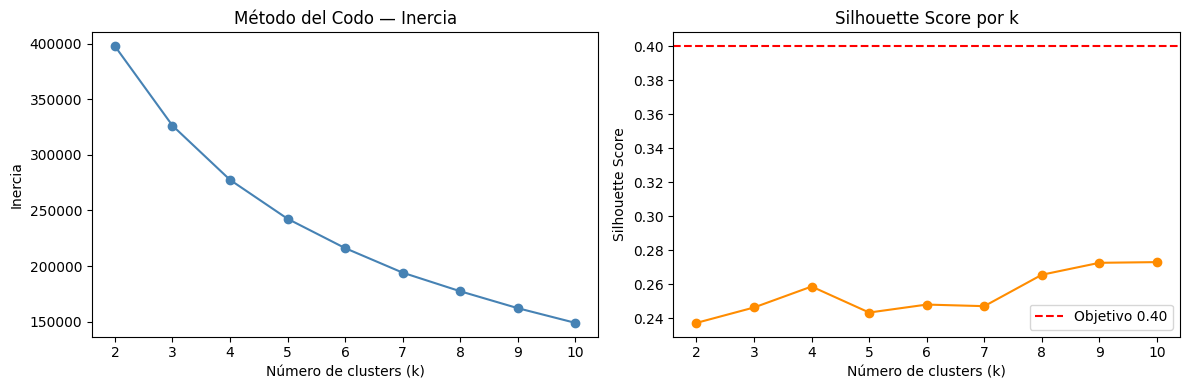

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_valores, inercias, marker='o', color='steelblue')
axes[0].set_title('Método del Codo — Inercia')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_valores, silhouettes, marker='o', color='darkorange')
axes[1].axhline(0.40, color='red', linestyle='--', label='Objetivo 0.40')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../../reports/figures/kmeans_codo.png')
plt.show()

## 5. Entrenar el modelo con k elegido

In [13]:
# Cambiar este valor según las gráficas del método del codo
K = 10

modelo = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = modelo.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['cluster'])
print(f"Clusters: {K}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Resultado: {'✓ cumple objetivo' if sil >= 0.40 else '✗ por debajo de 0.40'}")
print()
print("Clientes por cluster:")
print(df['cluster'].value_counts().sort_index())

Clusters: 10
Silhouette Score: 0.2730
Resultado: ✗ por debajo de 0.40

Clientes por cluster:
cluster
0    11311
1    11097
2    10280
3    11991
4    13657
5     7358
6     9883
7     4015
8    10021
9     9844
Name: count, dtype: int64


## 6. Visualizar clusters en 2D con PCA

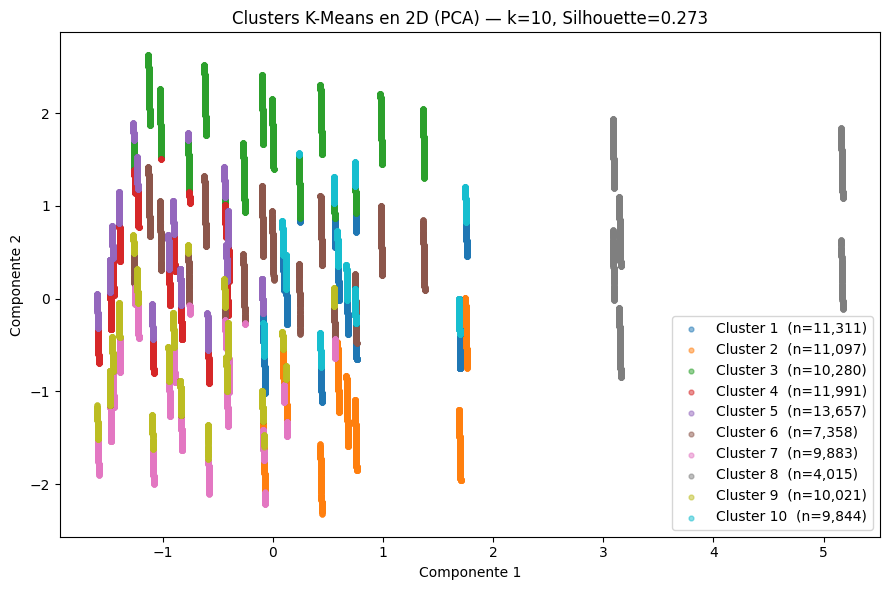

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

unique_clusters = sorted(df['cluster'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_clusters))

plt.figure(figsize=(9, 6))
for idx, c in enumerate(unique_clusters):
    sub = df[df['cluster'] == c]
    plt.scatter(sub['pca_x'], sub['pca_y'],
                label=f'Cluster {c+1}  (n={len(sub):,})',
                color=cmap(idx), alpha=0.5, s=12)

plt.title(f'Clusters K-Means en 2D (PCA) — k={K}, Silhouette={sil:.3f}')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/kmeans_pca.png')
plt.show()

## 7. Perfil de cada segmento

In [16]:
resumen = df.groupby('cluster').agg(
    n              = ('age', 'count'),
    edad_promedio  = ('age', 'mean'),
    gasto_promedio = ('total_spend', 'mean'),
    cantidad_prom  = ('quantity', 'mean'),
    categoria_top  = ('category', lambda x: x.value_counts().index[0]),
    pct_femenino   = ('gender', lambda x: (x == 'Female').mean() * 100),
    pago_frecuente = ('payment_method', lambda x: x.value_counts().index[0]),
).round(2)

resumen.index = [f'Cluster {i+1}' for i in resumen.index]
print(resumen.to_string())

                n  edad_promedio  gasto_promedio  cantidad_prom categoria_top  pct_femenino pago_frecuente
Cluster 1   11311          56.93         3566.92           4.14      Clothing        100.00           Cash
Cluster 2   11097          43.58         4051.71           4.48      Clothing          0.00           Cash
Cluster 3   10280          43.30         1261.58           2.83          Toys        100.00           Cash
Cluster 4   11991          56.46          452.84           1.74      Clothing        100.00           Cash
Cluster 5   13657          30.34          815.76           1.98      Clothing        100.00           Cash
Cluster 6    7358          43.07         1391.79           2.88          Toys          0.00           Cash
Cluster 7    9883          57.55          841.49           2.09      Clothing          0.00           Cash
Cluster 8    4015          43.43        18255.69           4.75         Shoes         59.75           Cash
Cluster 9   10021          29.44     

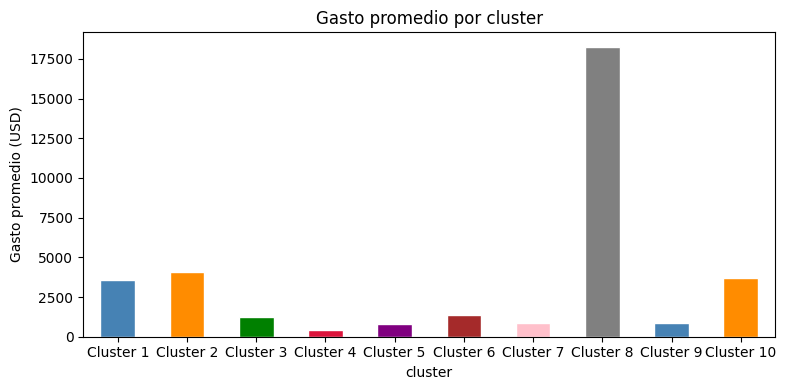

In [17]:
# Gráfica comparativa de gasto por cluster
gasto = df.groupby('cluster')['total_spend'].mean()

plt.figure(figsize=(8, 4))
gasto.plot(kind='bar', color=colores[:K], edgecolor='white')
plt.title('Gasto promedio por cluster')
plt.ylabel('Gasto promedio (USD)')
plt.xticks([i for i in range(K)],
           [f'Cluster {i+1}' for i in range(K)], rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/kmeans_perfiles.png')
plt.show()

## 8. Guardar resultados

In [18]:
# Exportar dataset con etiqueta de cluster
cols = ['invoice_no', 'customer_id', 'age', 'gender', 'category',
        'quantity', 'price', 'total_spend', 'payment_method',
        'shopping_mall', 'cluster']

output_csv = '../../reports/resultados/clientes_segmentados.csv'
df[cols].to_csv(output_csv, index=False)

print(f"Archivo guardado: {output_csv}")
print("Gráficas guardadas en: ../../reports/figures/")

Archivo guardado: ../../reports/resultados/clientes_segmentados.csv
Gráficas guardadas en: ../../reports/figures/
